# Project 1: Supply Chain Demand & Risk
## Exploration, cleaning, and feature engineering


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4)

## 1. Load the data and get a first look

In [8]:
df = pd.read_csv("project1_supply_chain_demand (1).csv")
df["date"] = pd.to_datetime(df["date"])

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Number of SKUs:", df["sku_id"].nunique())
df.head()

Shape: (4551, 7)
Date range: 2026-01-01 00:00:00 to 2026-06-29 00:00:00
Number of SKUs: 28


,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7
1,2026-01-02,SKU-1000,Snacks,278.0,0,125.0,7
2,2026-01-03,SKU-1000,Snacks,121.0,903,907.0,7
3,2026-01-04,SKU-1000,Snacks,75.0,0,832.0,7
4,2026-01-05,SKU-1000,Snacks,71.0,0,761.0,7


In [9]:
df.dtypes

date              datetime64[us]
sku_id                       str
category                     str
units_sold               float64
units_received             int64
closing_stock            float64
lead_time_days             int64
dtype: object

## 2. Explore: are there any data quality issues?

### 2.1 Missing values

units_sold       90
closing_stock    46
dtype: int64


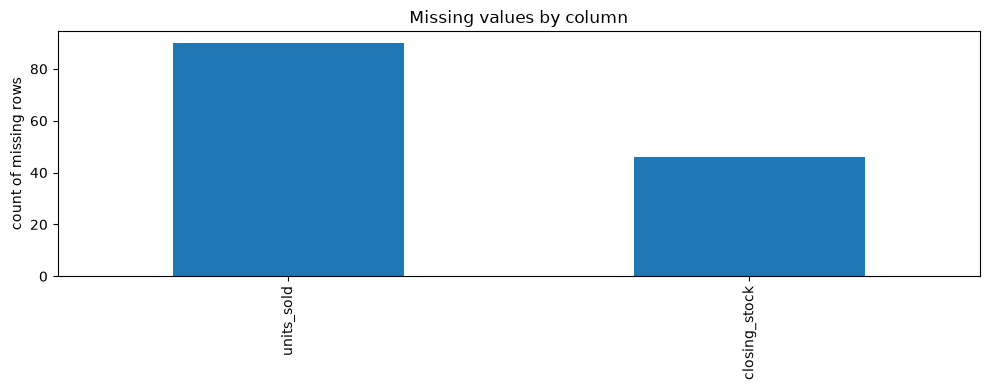

In [10]:
missing = df.isna().sum()
missing = missing[missing > 0]
print(missing)

missing.plot(kind="bar", title="Missing values by column")
plt.ylabel("count of missing rows")
plt.tight_layout()
plt.show()

**Finding:** `units_sold` and `closing_stock` both have missing values. We'll need to fill these before building rolling features, otherwise gaps will break the calculations.

### 2.2 Category values

In [11]:
df["category"].value_counts()

category
Beverages    1268
Snacks       1092
Sugar         898
Pasta         722
Flour         551
BEVERAGES       8
SNACKS          5
SUGAR           4
FLOUR           2
PASTA           1
Name: count, dtype: int64

**Finding:** the same category shows up twice with different casing, e.g. `Snacks` and `SNACKS` are being treated as two different categories. This needs to be standardized before we group or report by category.

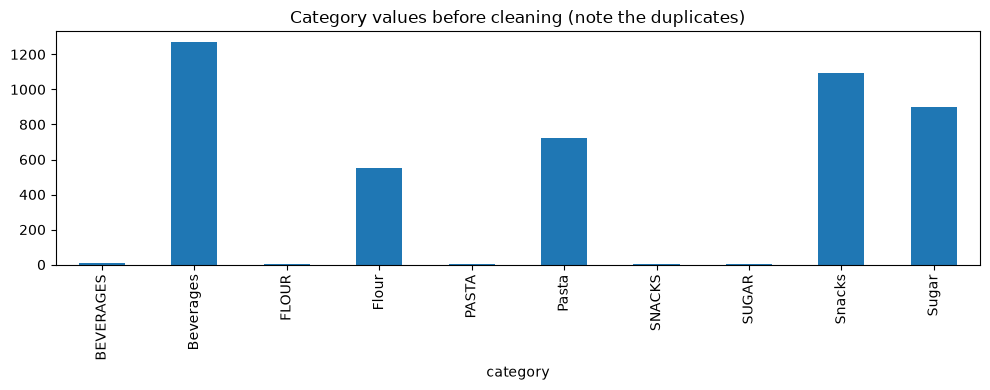

In [12]:
df["category"].value_counts().sort_index().plot(kind="bar", title="Category values before cleaning (note the duplicates)")
plt.tight_layout()
plt.show()

### 2.3 How much history does each SKU have?

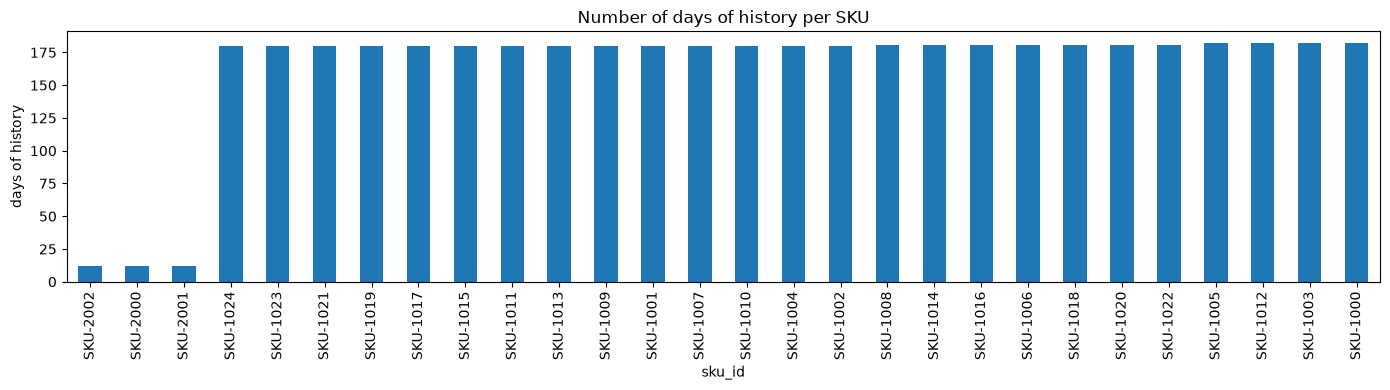

sku_id
SKU-2002     12
SKU-2000     12
SKU-2001     12
SKU-1024    180
SKU-1023    180
SKU-1021    180
Name: date, dtype: int64

In [13]:
sku_counts = df.groupby("sku_id")["date"].count().sort_values()
sku_counts.plot(kind="bar", figsize=(14,4), title="Number of days of history per SKU")
plt.ylabel("days of history")
plt.tight_layout()
plt.show()

sku_counts.head(6)

**Finding:** confirms the brief, 3 SKUs (`SKU-2000`, `SKU-2001`, `SKU-2002`) have only about 12 days of history, while the other 25 have roughly 6 months. 12 days is not enough to build reliable rolling averages or lag features, so these 3 need to be handled differently later.

### 2.4 Is lead_time_days actually fixed per SKU?

In [14]:
lead_time_variability = df.groupby("sku_id")["lead_time_days"].nunique().sort_values(ascending=False)
print(lead_time_variability.head(6))

inconsistent_skus = lead_time_variability[lead_time_variability > 1]
print(f"\nSKUs with more than one lead_time_days value: {list(inconsistent_skus.index)}")

sku_id
SKU-2002    5
SKU-2000    5
SKU-2001    4
SKU-1001    1
SKU-1024    1
SKU-1023    1
Name: lead_time_days, dtype: int64

SKUs with more than one lead_time_days value: ['SKU-2002', 'SKU-2000', 'SKU-2001']


**Finding:** a SKU's lead time should be a fixed property, it should not change day to day. But the 3 new SKUs each have several different `lead_time_days` values across their rows. This looks like a data quality issue, so we'll take the most common value per SKU as the true one.

### 2.5 Do stockouts already exist in this data?

Rows where closing_stock is exactly 0: 275


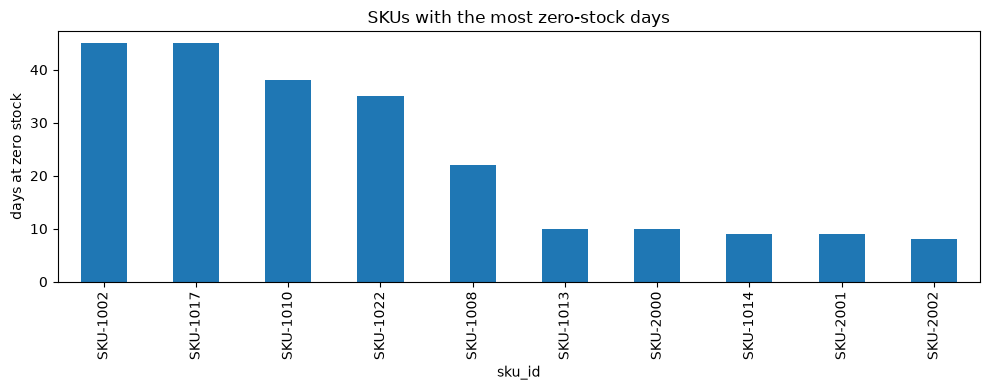

In [15]:
zero_stock_days = (df["closing_stock"] == 0).sum()
print(f"Rows where closing_stock is exactly 0: {zero_stock_days}")

zero_stock_by_sku = df[df["closing_stock"] == 0].groupby("sku_id").size().sort_values(ascending=False)
zero_stock_by_sku.head(10).plot(kind="bar", title="SKUs with the most zero-stock days")
plt.ylabel("days at zero stock")
plt.tight_layout()
plt.show()

**Finding:** stockouts are not hypothetical, they already happened in this data. This is useful later: we can sanity-check our risk flag by seeing whether it would have caught these before stock actually hit zero.

### 2.6 What does demand actually look like over time?

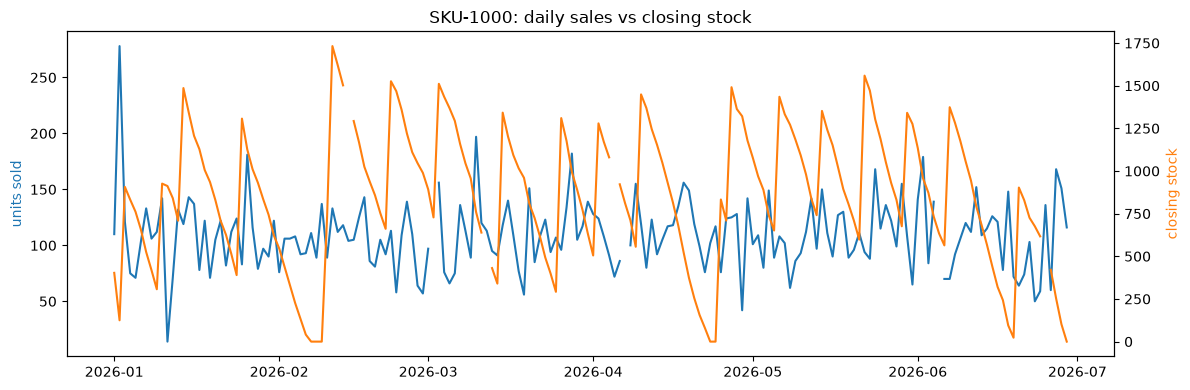

In [16]:
sample_sku = "SKU-1000"
sample = df[df["sku_id"] == sample_sku].sort_values("date")

fig, ax1 = plt.subplots(figsize=(12,4))
ax1.plot(sample["date"], sample["units_sold"], label="units sold", color="tab:blue")
ax1.set_ylabel("units sold", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(sample["date"], sample["closing_stock"], label="closing stock", color="tab:orange")
ax2.set_ylabel("closing stock", color="tab:orange")
plt.title(f"{sample_sku}: daily sales vs closing stock")
plt.tight_layout()
plt.show()

**Finding:** sales bounce around day to day (normal, noisy demand) while stock drops steadily between restocks then jumps back up when new stock arrives. This is exactly why a single day's sales number is not a reliable basis for a risk flag, we need a smoothed, recent-average view instead. That's what the rolling features below are for.

## 3. Clean the data

Based on what we found above, we fix three things.

In [17]:
# Fix 1: standardize category casing
df["category"] = df["category"].str.strip().str.title()

# confirm the fix worked
df["category"].value_counts()

category
Beverages    1276
Snacks       1097
Sugar         902
Pasta         723
Flour         553
Name: count, dtype: int64

In [18]:
# Fix 2: each SKU should have one fixed lead time. Use the most common (mode) value per SKU.
lead_time_fix = df.groupby("sku_id")["lead_time_days"].agg(lambda x: x.mode()[0])
df["lead_time_days"] = df["sku_id"].map(lead_time_fix)

# confirm every SKU now has exactly one lead_time_days value
df.groupby("sku_id")["lead_time_days"].nunique().value_counts()

lead_time_days
1    28
Name: count, dtype: int64

In [19]:
# Fix 3: fill missing values per SKU using the last known value
# (forward fill, then backward fill for any leading gaps)
df = df.sort_values(["sku_id", "date"]).reset_index(drop=True)
df["units_sold"] = df.groupby("sku_id")["units_sold"].transform(lambda x: x.ffill().bfill())
df["closing_stock"] = df.groupby("sku_id")["closing_stock"].transform(lambda x: x.ffill().bfill())

# confirm no missing values remain
df.isna().sum()

date              0
sku_id            0
category          0
units_sold        0
units_received    0
closing_stock     0
lead_time_days    0
dtype: int64

## 3.1 Confirm the cleaned data looks right

The checks above confirmed each individual fix worked. It is also worth looking at the data as a whole after cleaning, to make sure nothing broke and the overall picture still makes sense.

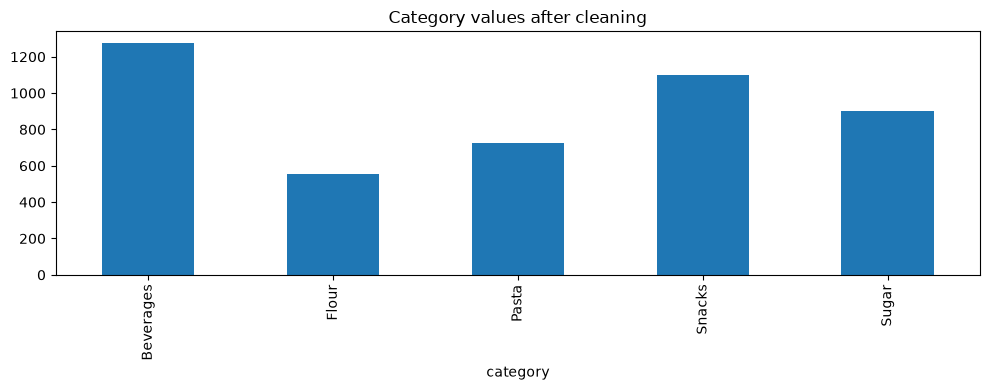

In [20]:
df["category"].value_counts().sort_index().plot(kind="bar", title="Category values after cleaning")
plt.tight_layout()
plt.show()

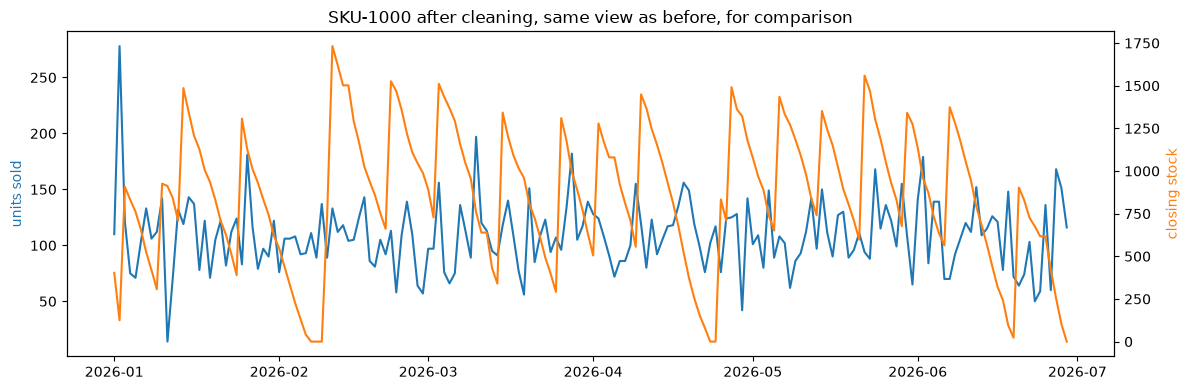

In [21]:
sample = df[df["sku_id"] == "SKU-1000"].sort_values("date")

fig, ax1 = plt.subplots(figsize=(12,4))
ax1.plot(sample["date"], sample["units_sold"], label="units sold", color="tab:blue")
ax1.set_ylabel("units sold", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(sample["date"], sample["closing_stock"], label="closing stock", color="tab:orange")
ax2.set_ylabel("closing stock", color="tab:orange")
plt.title("SKU-1000 after cleaning, same view as before, for comparison")
plt.tight_layout()
plt.show()

The category chart now shows one bar per category instead of duplicates, and the sales versus stock pattern for SKU-1000 still looks the same as before cleaning, since this SKU had no missing values to begin with. 

## 4. Separate established SKUs from new SKUs

Based on the history-length finding in section 2.3, we split SKUs with at least 30 days of history (enough for rolling/lag features) from the 3 new ones, which will get a simpler rule later instead of a forecast built on too little data.

In [22]:
sku_counts = df.groupby("sku_id")["date"].count()
new_skus = sku_counts[sku_counts < 30].index.tolist()
established_skus = sku_counts[sku_counts >= 30].index.tolist()

df["is_new_sku"] = df["sku_id"].isin(new_skus)

print(f"Established SKUs ({len(established_skus)}): enough history for forecasting features")
print(f"New SKUs ({len(new_skus)}): {new_skus} -- will use a simpler rule, not a forecast")

Established SKUs (25): enough history for forecasting features
New SKUs (3): ['SKU-2000', 'SKU-2001', 'SKU-2002'] -- will use a simpler rule, not a forecast


## 5. Feature engineering

This is the "time series made simple" part. Instead of specialized time series models, we turn each SKU's history into features a regular regression model can learn from:

- **Lag features**: sales 1 day ago, sales 7 days ago (gives the model memory of the recent past)
- **Rolling averages**: smoothed recent demand over 7 and 14 days (removes the daily noise we saw in section 2.6)
- **Demand trend**: is average demand rising or falling compared to a week ago
- **Day of week**: retail-style demand often has a weekly pattern
- **Days of cover**: current stock divided by average daily demand, the key business number for the risk flag later

In [23]:
df = df.sort_values(["sku_id", "date"]).reset_index(drop=True)

# Lag features
df["sold_lag_1"] = df.groupby("sku_id")["units_sold"].shift(1)
df["sold_lag_7"] = df.groupby("sku_id")["units_sold"].shift(7)

# Rolling averages (shift(1) first so we never use a day's own sales to predict itself)
df["sold_roll_mean_7"] = df.groupby("sku_id")["units_sold"].transform(lambda x: x.shift(1).rolling(7).mean())
df["sold_roll_mean_14"] = df.groupby("sku_id")["units_sold"].transform(lambda x: x.shift(1).rolling(14).mean())

# Trend: change in 7-day average demand vs a week ago
df["sold_roll_mean_7_prev"] = df.groupby("sku_id")["sold_roll_mean_7"].shift(7)
df["demand_trend"] = df["sold_roll_mean_7"] - df["sold_roll_mean_7_prev"]

# Day of week
df["day_of_week"] = df["date"].dt.dayofweek

# Days of cover: at current average daily demand, how many days will stock last
df["days_of_cover"] = df["closing_stock"] / df["sold_roll_mean_7"].replace(0, np.nan)

print("Done. New columns added:")
print([c for c in df.columns if c not in ["date","sku_id","category","units_sold","units_received","closing_stock","lead_time_days","is_new_sku"]])

Done. New columns added:
['sold_lag_1', 'sold_lag_7', 'sold_roll_mean_7', 'sold_roll_mean_14', 'sold_roll_mean_7_prev', 'demand_trend', 'day_of_week', 'days_of_cover']


### Check the smoothing actually worked, visually

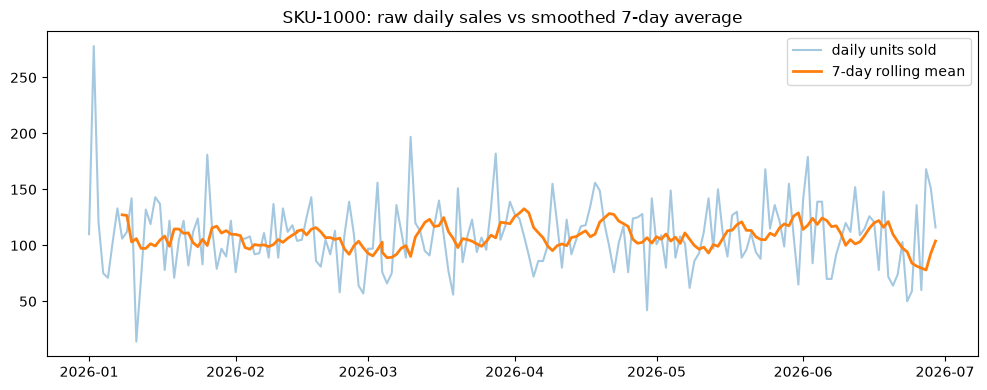

In [24]:
sample = df[df["sku_id"] == "SKU-1000"].sort_values("date")

plt.plot(sample["date"], sample["units_sold"], label="daily units sold", alpha=0.4)
plt.plot(sample["date"], sample["sold_roll_mean_7"], label="7-day rolling mean", linewidth=2)
plt.legend()
plt.title("SKU-1000: raw daily sales vs smoothed 7-day average")
plt.tight_layout()
plt.show()

**Confirms the point from section 2.6**: the rolling mean line is much smoother than raw daily sales, this is what the forecasting model will actually learn from.

### Preview the final feature table

In [25]:
df[df["sku_id"] == "SKU-1000"].tail(10)[
    ["date", "units_sold", "sold_lag_1", "sold_roll_mean_7",
     "demand_trend", "closing_stock", "days_of_cover", "lead_time_days"]
]

,date,units_sold,sold_lag_1,sold_roll_mean_7,demand_trend,closing_stock,days_of_cover,lead_time_days
172,2026-06-20,64.0,72.0,109.857143,6.714286,903.0,8.219766,7
173,2026-06-21,74.0,64.0,103.428571,-5.285714,829.0,8.015193,7
174,2026-06-22,103.0,74.0,97.571429,-17.571429,726.0,7.440703,7
175,2026-06-23,50.0,103.0,94.285714,-25.714286,676.0,7.169697,7
176,2026-06-24,59.0,50.0,84.142857,-38.000000,617.0,7.332767,7
177,2026-06-25,136.0,59.0,81.428571,-34.714286,617.0,7.577193,7
178,2026-06-26,60.0,136.0,79.714286,-41.571429,421.0,5.281362,7
179,2026-06-27,168.0,60.0,78.000000,-31.857143,253.0,3.243590,7
180,2026-06-28,151.0,168.0,92.857143,-10.571429,102.0,1.098462,7
181,2026-06-29,116.0,151.0,103.857143,6.285714,0.0,0.000000,7


## 6. Save the cleaned, feature-engineered table

We'll load this file in the next notebook to train the demand forecasting model.

In [26]:
df.to_csv("project1_features.csv", index=False)
print("Saved project1_features.csv, shape:", df.shape)

Saved project1_features.csv, shape: (4551, 16)
